# [Sequence To Sequence](https://wikidocs.net/24996)

seq2seq는 번역기에서 대표적으로 사용되는 모델입니다.

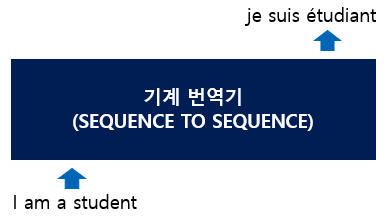

## Encoder
1. 인코더의 은닉 상태를 적절한 값(ex. 영벡터)으로 초기화한다.
2. 매 시점(time step)원문의 단어(token)가 입력되면(단어의 임베딩이 입력되면) 인코더는 이를 이용해 은닉 상태를 업데이트를 한다.
3. 입력 시퀀스의 끝까지 이 과정을 반복하면 인코더의 최종 은닉 상태는 입력 시퀀스의 정보를 압축 요약한 정보를 담고 있게 된다.
4. 이 마지막 시점에서의 인코더 은닉 상태를 컨텍스트 벡터라고 하고, 이 값은 디코더로 넘어간다.

## Decoder
1. 디코더는 전달받은 컨텍스트 벡터로 자신의 은닉 상태를 초기화한다.
2. 그리고 매 시점 자신이 바로 직전 시점에 출력했던 단어를 입력으로 받아, 자신의 은닉 상태를 업데이트하고, 이를 이용해 다음 단어를 예측한다. (최초 시점에서는 시퀀스 시작을 의미하는 `<sos>` 토큰(Start Of Sequence)을 입력으로 받는다.)
3. 이 과정을 정해진 반복 횟수 또는 시퀀스 끝을 나타내는 `<eos>` 토큰(End Of Sequence)이 나올 때까지 수행한다.

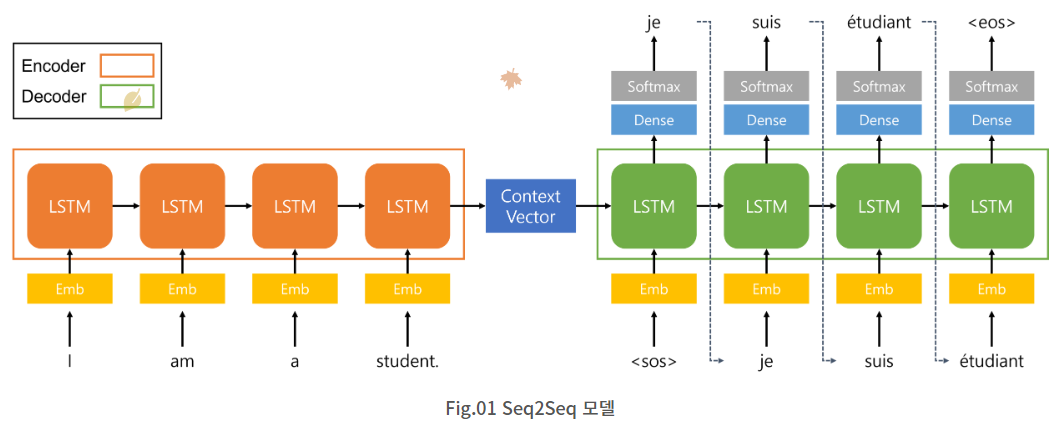

# 예제1

In [1]:
import numpy as np
import torch
import torch.nn as nn

In [2]:
n_step = 5 # 글자의 최대 길이
n_hidden = 128

## 데이터

### 데이터 생성

In [7]:
seq_data = [['man', 'women'], ['black', 'white'], ['king', 'queen'], ['girl', 'boy'], ['up', 'down'], ['high', 'low']]
np.array(seq_data).shape

(6, 2)

In [8]:
batch_size = len(seq_data)
batch_size

6

### 데이터 토큰화

In [9]:
char_arr = [c for c in 'SEPabcdefghijklmnopqrstuvwxyz'] # S(시작), E(끝), P(패딩)
len(char_arr)

29

### 데이터 사전

In [10]:
num_dic = {n: i for i, n in enumerate(char_arr)}
n_class = len(num_dic)
n_class

29

In [11]:
char_arr[5], num_dic['c']

('c', 5)

## 학습 데이터

### 학습 데이터 생성

In [13]:
import numpy as np

def make_batch():
    encoder_batch, decoder_batch, target_batch = [], [], []

    for seq in seq_data: # [['man', 'women']]
        ##############################################
        # 패딩 작업 
        ##############################################
        for i in range(2): # ['manPP', 'women']
            seq[i] = seq[i] + 'P' * (n_step - len(seq[i])) # P(2): 패딩

        ##############################################
        # encoder & decoder & target 생성 
        ##############################################
        encoder_seq = seq[0] # 'manPP'
        encoder = [num_dic[n] for n in encoder_seq] # [3,4,5...]

        decoder_seq = seq[1] # 'women'
        # S(0): 시작
        decoder = [num_dic[n] for n in ('S' + decoder_seq)] # [0,7,8,9...]
        # E(1): 끝
        target = [num_dic[n] for n in (decoder_seq + 'E')] # [7,8,9..,1]

        ##############################################
        # encoder & decoder => 임베딩 처리 
        ##############################################
        encoder_batch.append(np.eye(n_class)[encoder]) # one-hot [[...],[...],[...],...]
        decoder_batch.append(np.eye(n_class)[decoder]) # one-hot [[...],[...],[...],...]
        target_batch.append(target) # not one-hot

    ##############################################
    # tensor로 형변환  
    # torch.FloatTensor(encoder_batch) -> (전체데이터, seq_len, embedding)
    # torch.FloatTensor(decoder_batch) -> (전체데이터, seq_len+1, embedding)
    # torch.LongTensor(target_batch)   -> (전체데이터, seq_len+1)
    ##############################################
    return torch.FloatTensor(np.array(encoder_batch)), torch.FloatTensor(np.array(decoder_batch)), torch.LongTensor(np.array(target_batch))


In [14]:
input_batch, output_batch, target_batch = make_batch()

# input_batch: (batch_size(데이터 수), input_size(최대 글자 수), embedding_size(원핫인코딩 수))
# output_batch: (batch_size(데이터 수), input_size(1(S) + 최대 글자 수), embedding_size(원핫인코딩 수))
# target_batch: ((batch_size(데이터 수), input_size(1(S) + 최대 글자 수))
input_batch.shape, output_batch.shape, target_batch.shape

(torch.Size([6, 5, 29]), torch.Size([6, 6, 29]), torch.Size([6, 6]))

### 디버깅

In [15]:
seq_data

[['manPP', 'women'],
 ['black', 'white'],
 ['kingP', 'queen'],
 ['girlP', 'boyPP'],
 ['upPPP', 'downP'],
 ['highP', 'lowPP']]

In [16]:
# 1. 데이터 구조 파악 : 리스트1 , 리스트2
# 2. 리스트2에서 가장 큰 길이를 찾아서 새로운 리스트3에 담음
# 2-1. 리스트3: 리스트2에서 가장 큰 길이들이 모임
# 3. 리스트3에서 가장 큰 수 찾음
tmp = [ len(row[0]) if len(row[0]) > len(row[1]) else len(row[1]) for row in seq_data ]
tmp

[5, 5, 5, 5, 5, 5]

In [17]:
max(tmp)

5

In [18]:
n_step # 글자의 최대 길이

5

In [19]:
for seq in [['man', 'women']]:
    for i in range(2):
        seq[i] = seq[i] + 'P' * (n_step - len(seq[i])) # P(2): 패딩

    input = [num_dic[n] for n in seq[0]]
    output = [num_dic[n] for n in ('S' + seq[1])] # S(0): 시작
    target = [num_dic[n] for n in (seq[1] + 'E')] # E(1): 끝

    break

In [20]:
seq

['manPP', 'women']

In [21]:
input

[15, 3, 16, 2, 2]

In [22]:
output

[0, 25, 17, 15, 7, 16]

In [23]:
target

[25, 17, 15, 7, 16, 1]

In [24]:
len(np.eye(n_class)[input]) # 5개 글자!!!

5

In [25]:
np.eye(n_class)[input][0] # 글자별 원핫인코딩!!

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## Seq2Seq 모델 생성

In [27]:
import torch

device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Encoder RNN Layer

In [38]:
class Encoder_Layer(nn.Module):
    def __init__(self, embedding_size, hidden_size, num_layers, is_bi_direction=False, device="cpu"):
        super().__init__()
        self.device = device
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.is_bi_direction = 2 if is_bi_direction else 1
        self.rnn = nn.RNN(input_size=embedding_size, hidden_size=hidden_size
                          , num_layers=num_layers, dropout=0.5,
                         bidirectional=is_bi_direction)

    def forward(self, features): # (batch, seq_len, embedding)
        init_state = torch.zeros(self.is_bi_direction*self.num_layers, 
                                 features.shape[0], self.hidden_size).to(self.device)
        
        outputs, hidden_states = self.rnn(features.permute(1,0,2), init_state)
        return hidden_states

In [64]:
encoder_layer = Encoder_Layer(embedding_size=29, hidden_size=8, num_layers=2, device=device).to(device)

In [65]:
# input_batch, output_batch
enc_states = encoder_layer(input_batch)
enc_states.shape

torch.Size([2, 6, 8])

In [66]:
import torchinfo

torchinfo.summary(
    encoder_layer, (128, 50, 29)
)

Layer (type:depth-idx)                   Output Shape              Param #
Encoder_Layer                            [2, 128, 8]               --
├─RNN: 1-1                               [50, 128, 8]              456
Total params: 456
Trainable params: 456
Non-trainable params: 0
Total mult-adds (M): 2.92
Input size (MB): 0.74
Forward/backward pass size (MB): 0.41
Params size (MB): 0.00
Estimated Total Size (MB): 1.15

### Decoder RNN Layer

In [47]:
class Decoder_Layer(nn.Module):
    def __init__(self, embedding_size, hidden_size, num_layers, is_bi_direction=False, device="cpu"):
        super().__init__()
        self.device = device
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.is_bi_direction = 2 if is_bi_direction else 1
        self.rnn = nn.RNN(input_size=embedding_size, hidden_size=hidden_size
                          , num_layers=num_layers, dropout=0.5,
                         bidirectional=is_bi_direction)

    def forward(self, features, enc_hidden_states): # (batch, seq_len, embedding)
        
        outputs, hidden_states = self.rnn(features.permute(1,0,2), enc_hidden_states)
        return outputs # (seq_len, batch, hidden)

In [67]:
decoder_layer = Decoder_Layer(embedding_size=29, hidden_size=8, num_layers=2, device=device).to(device)

In [68]:
dec_outputs = decoder_layer(output_batch, enc_states)
dec_outputs.shape

torch.Size([6, 6, 8])

In [70]:
torchinfo.summary(
    decoder_layer, [(128, 50, 29), (2, 128, 8)]
)

Layer (type:depth-idx)                   Output Shape              Param #
Decoder_Layer                            [50, 128, 8]              --
├─RNN: 1-1                               [50, 128, 8]              456
Total params: 456
Trainable params: 456
Non-trainable params: 0
Total mult-adds (M): 2.92
Input size (MB): 0.75
Forward/backward pass size (MB): 0.41
Params size (MB): 0.00
Estimated Total Size (MB): 1.16

### FC Layer

In [50]:
class FC_Layer(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size*2),
            nn.ReLU(),
            nn.Linear(hidden_size*2, vocab_size)
        )

    def forward(self, features): # (batch, hidden)
        return self.fc(features) # (batch, vocab)

In [51]:
fc_layer = FC_Layer(vocab_size=n_class, hidden_size=8)

In [71]:
pred = fc_layer(dec_outputs)
pred.shape

torch.Size([6, 6, 29])

In [72]:
torchinfo.summary(
    fc_layer, (50, 128, 8)
)

Layer (type:depth-idx)                   Output Shape              Param #
FC_Layer                                 [50, 128, 29]             --
├─Sequential: 1-1                        [50, 128, 29]             --
│    └─Linear: 2-1                       [50, 128, 16]             144
│    └─ReLU: 2-2                         [50, 128, 16]             --
│    └─Linear: 2-3                       [50, 128, 29]             493
Total params: 637
Trainable params: 637
Non-trainable params: 0
Total mult-adds (M): 0.03
Input size (MB): 0.20
Forward/backward pass size (MB): 2.30
Params size (MB): 0.00
Estimated Total Size (MB): 2.51

### Create Seq2Seq Model

In [59]:
class Seq2Seq(nn.Module):
    def __init__(self,
        embedding_size, hidden_size, num_layers, n_class, device
    ):
        super().__init__()
        self.enc_rnn = Encoder_Layer(embedding_size=embedding_size, hidden_size=hidden_size
                                     , num_layers=num_layers, device=device).to(device)
        self.dec_rnn = Decoder_Layer(embedding_size=embedding_size, hidden_size=hidden_size
                                     , num_layers=num_layers, device=device).to(device)
        self.fc = FC_Layer(vocab_size=n_class, hidden_size=hidden_size).to(device)
        
    def forward(self, enc_input, dec_input): 
        """
        enc_input -> (batch, seq_len, embedding)
        dec_input -> (batch, seq_len+1, embedding)
        """

        # enc_states : [num_layers(=1) * num_directions(=1), batch_size, n_hidden]
        enc_states = self.enc_rnn(enc_input)

        # dec_outputs : [seq_len+1(=6), batch_size, hidden]
        dec_outputs = self.dec_rnn(dec_input, enc_states)

        _outputs = dec_outputs.transpose(0, 1) # _outputs (batch_size, seq_len+1(=6), hidden)
        pred = self.fc(_outputs) # pred : [batch_size, seq_len+1(=6), n_class]
        return pred

In [60]:
seq2seq = Seq2Seq(embedding_size=n_class, hidden_size=8, num_layers=2, n_class=n_class, device=device).to(device)

In [62]:
torchinfo.summary(
    seq2seq, [(128, 50, 29), (128, 51, 29)]
)

Layer (type:depth-idx)                   Output Shape              Param #
Seq2Seq                                  [128, 51, 29]             --
├─Encoder_Layer: 1-1                     [2, 128, 8]               --
│    └─RNN: 2-1                          [50, 128, 8]              456
├─Decoder_Layer: 1-2                     [51, 128, 8]              --
│    └─RNN: 2-2                          [51, 128, 8]              456
├─FC_Layer: 1-3                          [128, 51, 29]             --
│    └─Sequential: 2-3                   [128, 51, 29]             --
│    │    └─Linear: 3-1                  [128, 51, 16]             144
│    │    └─ReLU: 3-2                    [128, 51, 16]             --
│    │    └─Linear: 3-3                  [128, 51, 29]             493
Total params: 1,549
Trainable params: 1,549
Non-trainable params: 0
Total mult-adds (M): 5.98
Input size (MB): 1.50
Forward/backward pass size (MB): 3.18
Params size (MB): 0.01
Estimated Total Size (MB): 4.68

## 학습

In [121]:
model = Seq2Seq(embedding_size=n_class, hidden_size=64, num_layers=2, n_class=n_class, device=device).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [122]:
input_batch, output_batch, target_batch = make_batch()

input_batch.shape, output_batch.shape, target_batch.shape

(torch.Size([6, 5, 29]), torch.Size([6, 6, 29]), torch.Size([6, 6]))

In [123]:
for epoch in range(10000):
    ###################################
    # 모델 학습 
    ###################################
    output = model(input_batch, output_batch)

    ###################################
    # 각 단어별 오차 계산  
    ###################################
    loss = 0
    for i in range(0, len(target_batch)):
        loss += criterion(output[i], target_batch[i])

    ###################################
    # 학습 진행별 결과 프린트  
    ###################################
    if (epoch + 1) % 1000 == 0:
        print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.6f}'.format(loss))

    ###################################
    # 오차에 대한 모델 파라미터 업데이트   
    ###################################
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


Epoch: 1000 cost = 0.002282
Epoch: 2000 cost = 0.000500
Epoch: 3000 cost = 0.000192
Epoch: 4000 cost = 0.000079
Epoch: 5000 cost = 0.000033
Epoch: 6000 cost = 0.000017
Epoch: 7000 cost = 0.000015
Epoch: 8000 cost = 0.000009
Epoch: 9000 cost = 0.000003
Epoch: 10000 cost = 0.000002


## 테스트

In [124]:
def make_testbatch(input_word):
    ################################
    # 모델 input 데이터셋 정의 
    ################################
    encoder_batch, decoder_batch = [], []

    ################################
    # 모델 input 데이터셋 전처리
    ################################   
    encoder_words = input_word + 'P' * (n_step - len(input_word)) # P: 패딩 추가
    encoder_index = [num_dic[word] for word in encoder_words] # 토큰 to index 변환 
    decoder_words = 'S' + 'P' * n_step # S(시작토큰) + P(패딩토큰): input으로 의미없는 스패셜 토큰(P)으로 초기화 
    print(f'encoder_words: {encoder_words} / decoder_words: {decoder_words}')
    decoder_index = [num_dic[word] for word in decoder_words] # S와 P로 output 구성

    encoder_batch = np.eye(n_class)[encoder_index] # Embedding 추가 
    decoder_batch = np.eye(n_class)[decoder_index] # Embedding 추가 

    ################################
    # 모델 input 데이터셋 tensor 형변환 & batch 차원 추가 
    ################################ 
    return torch.FloatTensor(encoder_batch).unsqueeze(0), torch.FloatTensor(decoder_batch).unsqueeze(0)

In [125]:
n_step # 문자의 최대 길이 

5

In [126]:
input_batch, output_batch = make_testbatch('man')
input_batch.shape, output_batch.shape

encoder_words: manPP / decoder_words: SPPPPP


(torch.Size([1, 5, 29]), torch.Size([1, 6, 29]))

In [127]:
output = model(input_batch, output_batch)
output.shape

torch.Size([1, 6, 29])

In [128]:
output[0][0] # 첫번째 글자의 예측 데이터 

tensor([-11.9321, -10.9800, -22.7925, -12.9760,   7.1643, -11.6731,   2.6603,
         -5.0358, -11.6418, -11.6468,  -8.6153,   0.2089, -10.8610, -10.4626,
         -9.4973, -10.2014, -25.1622,  -6.6509, -12.8827,  -6.8952, -10.9149,
        -11.6467, -18.9396,  -2.2887, -11.5191,  22.6155, -10.5700,   1.9509,
        -12.0311], grad_fn=<SelectBackward0>)

In [129]:
output.data.max(2, keepdim=True) # values: 최대값, indices: 인덱스값

torch.return_types.max(
values=tensor([[[22.6155],
         [15.8452],
         [19.8679],
         [24.8842],
         [20.0416],
         [22.2355]]]),
indices=tensor([[[25],
         [17],
         [15],
         [ 7],
         [16],
         [ 1]]]))

In [130]:
predict = output.data.max(2, keepdim=True)[1]

# (batch, seq_len, index정보)
predict.shape

torch.Size([1, 6, 1])

In [131]:
predict

tensor([[[25],
         [17],
         [15],
         [ 7],
         [16],
         [ 1]]])

In [132]:
decoded = [char_arr[i] for i in predict[0]]
decoded # E: 문장의 끝을 나타냄, P: 패딩

['w', 'o', 'm', 'e', 'n', 'E']

In [133]:
# Test
def translate(word):
    input_batch, output_batch = make_testbatch(word)

    output = model(input_batch, output_batch)
    # output : [max_len+1(=6), batch_size(=1), n_class]

    predict = output.data.max(2, keepdim=True)[1] # select n_class dimension
    decoded = [char_arr[i] for i in predict[0]]
    try:
        end = decoded.index('E')
        translated = ''.join(decoded[:end])
    except:
        translated = ''.join(decoded)

    return translated.replace('P', '')

In [134]:
print('test')
print('man ->', translate('man'))
print('mans ->', translate('mans'))
print('king ->', translate('king'))
print('black ->', translate('black'))
print('upp ->', translate('upp'))

test
encoder_words: manPP / decoder_words: SPPPPP
man -> women
encoder_words: mansP / decoder_words: SPPPPP
mans -> women
encoder_words: kingP / decoder_words: SPPPPP
king -> queen
encoder_words: black / decoder_words: SPPPPP
black -> white
encoder_words: uppPP / decoder_words: SPPPPP
upp -> down


# 예제2(영어->한글)

In [135]:
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm
import random
import os

In [136]:
def reset_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

In [137]:
SEED = 42

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Load Data

In [241]:
DATA_PATH = "./data/"

In [242]:
train = pd.read_csv(f"{DATA_PATH}translate_en_ko.csv")

train = train[:500]
print(train.shape)
train.head()

(500, 2)


,en,ko
0,These products are of the same quality.,이 제품들은 같은 품질이다.
1,The meeting was cancelled.,미팅이 취소되었다.
2,They found this.,그들이 이것을 찾았다.
3,Tom didn't tell Mary why he had to work late.,톰은 메리에게 왜 그가 늦게까지 일해야 했는지 알려주지 않았다.
4,After you.,먼저 가세요.


## Text Preprocessing

### Cleaning
- 알파벳 , 숫자, 공백, 마침표, 쉼표, 느낌표, 물음표

In [243]:
train["en"] = train["en"].str.replace("[^a-zA-Z0-9 .,!?\'\"]" , "",regex=True).str.lower()
train["ko"] = train["ko"].str.replace("[^가-힣0-9 .,!?\'\"]" , "",regex=True)

In [244]:
train.head()

,en,ko
0,these products are of the same quality.,이 제품들은 같은 품질이다.
1,the meeting was cancelled.,미팅이 취소되었다.
2,they found this.,그들이 이것을 찾았다.
3,tom didn't tell mary why he had to work late.,톰은 메리에게 왜 그가 늦게까지 일해야 했는지 알려주지 않았다.
4,after you.,먼저 가세요.


### 토큰 & 어휘집

#### 한글

In [245]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

In [246]:
result = kiwi.tokenize(train["ko"])

src_data = []
for tokens in result:
    tokens = [ t.form for t in tokens]
    src_data.append(tokens)

In [247]:
from torchtext.vocab import build_vocab_from_iterator

vocab_ko = build_vocab_from_iterator(src_data,specials=["<pad>","<unk>"])
vocab_ko.set_default_index(vocab_ko["<unk>"])
len(vocab_ko)

885

In [248]:
src_data = [ vocab_ko(tokens) for tokens in src_data ]
src_data[0]

[5, 779, 31, 9, 41, 9, 857, 5, 10, 2]

#### 영어

In [249]:
from torchtext.data.utils import get_tokenizer
tokenizer = get_tokenizer("basic_english")

In [250]:
sos_token = "<sos>"
eos_token = "<eos>"

In [251]:
tgt_data = []
for text in train["en"]:
    tokens = [sos_token] + tokenizer(text) + [eos_token]
    tgt_data.append(tokens)

In [252]:
from torchtext.vocab import build_vocab_from_iterator

# sepcials => [<pad>, <unk>, <sos>, <eos>]
# sepcials의 index => [0, 1, 2, 3] 
vocab_en = build_vocab_from_iterator(tgt_data, specials=["<pad>","<unk>", sos_token, eos_token])
vocab_en.set_default_index(vocab_en["<unk>"])
len(vocab_en)

837

In [253]:
tgt_data = [ vocab_en(tokens) for tokens in tgt_data]

## Dataset

In [254]:
from torch.utils.data import Dataset

In [255]:
class TranslateDataset(Dataset):
    def __init__(self,src,tgt):
        self.src = src
        self.tgt = tgt

    def __len__(self):
        return len(self.src)

    def __getitem__(self,idx):
        item = {}
        item["src"] = torch.tensor(self.src[idx])
        item["tgt"] = torch.tensor(self.tgt[idx])
        return item

In [256]:
dt = TranslateDataset(src_data,tgt_data)
len(dt)

500

In [257]:
dt[0]

{'src': tensor([  5, 779,  31,   9,  41,   9, 857,   5,  10,   2]),
 'tgt': tensor([  2, 183, 688,  27,  30,  14, 283, 693,   4,   3])}

### collate_fn

- torch.nn.utils.rnn.pad_sequence
    - 첫번째 인수로 정수번호로 이루어진 1차원 텐서들을 담은 리스트 전달
    - 리스트 안의 텐서에 최대 길이에 맞춰 패딩해줘서 텐서로 반환
    - batch_first = True 주면 batch 차원을 앞에다가 넣어서 전달해도 된다.

In [258]:
x = [ torch.tensor(lst) for lst in src_data[:4]]
x

[tensor([  5, 779,  31,   9,  41,   9, 857,   5,  10,   2]),
 tensor([544,   5, 823,  33,   6,  10,   2]),
 tensor([ 22,  31,   5,  84,  12, 146,   6,  10,   2]),
 tensor([  8,   9,  59,  44, 142,  22,  14, 167,  37, 124,  58,   4,  62,   4,
           6, 166, 291,   3,  45,  23,  34,   6,  10,   2])]

In [259]:
torch.nn.utils.rnn.pad_sequence(x,batch_first=True)

tensor([[  5, 779,  31,   9,  41,   9, 857,   5,  10,   2,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [544,   5, 823,  33,   6,  10,   2,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [ 22,  31,   5,  84,  12, 146,   6,  10,   2,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  8,   9,  59,  44, 142,  22,  14, 167,  37, 124,  58,   4,  62,   4,
           6, 166, 291,   3,  45,  23,  34,   6,  10,   2]])

In [260]:
def collate_fn(samples):
    # print(samples)
    src = [ sample["src"] for sample in samples ]
    tgt = [ sample["tgt"] for sample in samples ]

    src = torch.nn.utils.rnn.pad_sequence(src, batch_first=True)
    tgt = torch.nn.utils.rnn.pad_sequence(tgt, batch_first=True)
    return {"src":src, "tgt":tgt }

## DataLoader

In [261]:
from torch.utils.data import DataLoader

In [262]:
dl = DataLoader(dt,batch_size=2, shuffle=False, collate_fn= collate_fn)
batch = next(iter(dl))
batch

{'src': tensor([[  5, 779,  31,   9,  41,   9, 857,   5,  10,   2],
         [544,   5, 823,  33,   6,  10,   2,   0,   0,   0]]),
 'tgt': tensor([[  2, 183, 688,  27,  30,  14, 283, 693,   4,   3],
         [  2,  14, 630,  22, 413,   4,   3,   0,   0,   0]])}

In [263]:
# (batch, seq_len)
batch['src'].shape, batch['tgt'].shape 

(torch.Size([2, 10]), torch.Size([2, 10]))

## Model

### Encoder

In [264]:
class Encoder(torch.nn.Module):
    def __init__(self,enc_vocab_size, embedding_dim, layer_size=1, is_bidirection=False, device="cpu"):
        super().__init__()
        self.hidden_size = embedding_dim*2
        self.layer_size = layer_size
        self.is_bidirection = 2 if is_bidirection else 1
        self.device = device
        
        self.emb_layer = torch.nn.Embedding(enc_vocab_size, embedding_dim)
        self.rnn_layer = torch.nn.LSTM(
            input_size=embedding_dim,      # LSTM의 input 크기 
            hidden_size=embedding_dim*2,   # layer에 있는 LSTM 모델의 수 
            num_layers=layer_size,         # layer의 수 
            bidirectional=is_bidirection,  # 학습방향 
            batch_first=True               # batch 차원의 위치 
        )

    def __create_init_states(self, batch_size):
        init_hidden = torch.zeros(
            self.layer_size*self.is_bidirection, batch_size, self.hidden_size
        ).to(self.device)
        init_cell = torch.zeros(
            self.layer_size*self.is_bidirection, batch_size, self.hidden_size
        ).to(self.device)

        return init_hidden, init_cell

    def forward(self, features): # (batch, seq_len)
        init_hidden, init_cell = self.__create_init_states(features.shape[0])
        
        emb_out = self.emb_layer(features) # (batch, seq_len, embedding)
        outputs, (hidden_states, cell_states) = self.rnn_layer(emb_out, (init_hidden, init_cell))
        
        return hidden_states, cell_states # (layer*direction, batch, hidden)

In [265]:
encoder = Encoder(len(vocab_ko),64).to(device)
hn, cn = encoder(batch["src"])
hn.shape, cn.shape

(torch.Size([1, 2, 128]), torch.Size([1, 2, 128]))

### Decoder

In [266]:
class Decoder(torch.nn.Module):
    def __init__(self,dec_vocab_size, embedding_dim, layer_size=1, is_bidirection=False, device="cpu"):
        super().__init__()
        self.emb_layer = torch.nn.Embedding(dec_vocab_size, embedding_dim)
        self.rnn_layer = torch.nn.LSTM(
            input_size=embedding_dim,      # LSTM의 input 크기 
            hidden_size=embedding_dim*2,   # layer에 있는 LSTM 모델의 수 
            num_layers=layer_size,         # layer의 수 
            bidirectional=is_bidirection,  # 학습방향 
            batch_first=True               # batch 차원의 위치 
        )
        self.fc_layer = nn.Sequential(
            torch.nn.Linear(embedding_dim*2, embedding_dim*2),
            torch.nn.ReLU(),
            torch.nn.Linear(embedding_dim*2, dec_vocab_size)
        )

    def forward(self, features, enc_hidden_states, enc_cell_states):
        emb_out = self.emb_layer(features)
        outputs, (hidden, cell) = self.rnn_layer(emb_out, (enc_hidden_states, enc_cell_states) )
        # hn -> n_layer, batch, features
        prediction = self.fc_layer(hidden[-1])
        return prediction, hidden, cell

In [267]:
decoder_model = Decoder(dec_vocab_size=len(vocab_en), embedding_dim=64).to(device)

In [268]:
batch["tgt"].shape, hn.shape, cn.shape

(torch.Size([2, 10]), torch.Size([1, 2, 128]), torch.Size([1, 2, 128]))

In [269]:
prediction, hidden, cell = decoder_model(batch["tgt"], hn, cn)

prediction.shape, hidden.shape, cell.shape

(torch.Size([2, 837]), torch.Size([1, 2, 128]), torch.Size([1, 2, 128]))

### Seq2Seq Model

In [270]:
class Net(torch.nn.Module):
    def __init__(self,vocab_size_src, vocab_size_tgt ,embedding_dim = 512,device = "cpu"):
        super().__init__()
        self.encoder = Encoder(vocab_size_src, embedding_dim)
        self.decoder = Decoder(vocab_size_tgt, embedding_dim)

        self.vocab_size_tgt = vocab_size_tgt
        self.device = device
        
    def forward(self, src, tgt, enc_hidden = None, enc_cell = None, teacher_forcing_ratio = 0.5):
        ##########################################
        # tgt -> (batch, seq_len)
        ##########################################
        batch_size = tgt.shape[0]
        tgt_len = tgt.shape[1]

        ##########################################
        # prediction 예측 결과 데이터 초기화 
        # prediction -> (batch, tgt_seq_len, tgt_vocab)
        ##########################################       
        prediction = torch.zeros(batch_size, tgt_len, self.vocab_size_tgt).to(self.device)

        ##########################################
        # encoder 모델이 학습하지 않았다면, 실행 
        ########################################## 
        if enc_hidden is None:
            enc_hidden, enc_cell = self.encoder(src)

        ##########################################
        # tgt -> (batch, seq_len)
        # tgt[:,0] -> (batch(=sos[스패셜토큰]), )
        # tgt[:,0].view(-1,1) -> (batch, sos[스패셜토큰])
        ##########################################       
        dec_input = tgt[:,0].view(-1,1)

        ##########################################
        # tgt_len -> decoder input의 문장 길이 
        # 쉽게 얘기해서 하나의 단어씩 decoder가 학습 진행 
        ##########################################     
        for tgt_index in range(1, tgt_len):
            ##########################################
            # 하나의 단어 학습 진행
            # output: dec_input의 학습결과에 대한 예측정보(tgt_vocab 예측값) 
            # output: (batch, tgt_vocab)
            ########################################## 
            output, enc_hidden, enc_cell = self.decoder(dec_input, enc_hidden, enc_cell)
            ##########################################
            # 예측한 결과 해당 위치에 추가 
            # prediction -> (batch, tgt_seq_len, tgt_vocab)
            # prediction[:, tgt_index] -> (batch, tgt_vocab)
            ##########################################
            prediction[:, tgt_index] = output

            ##########################################
            # 다음 학습을 위한 모델의 예측값(output)를 dec_input 정의 
            # output -> (batch, tgt_vocab)
            # output.argmax(dim=1) -> (batch(=index),)
            # output.argmax(dim=1).view(-1,1) -> (batch, index)
            ##########################################
            dec_input = output.argmax(dim=1).view(-1,1)

            ##########################################
            # 교사 강요 옵션
            # 랜덤 확률(random)에 따라 모델의 예측값(output)이 아닌  
            # 정답 데이터(tgt[:,t]) 다음 학습의 dec_input 정의 
            ##########################################
            if random.random() < teacher_forcing_ratio:
                dec_input = tgt[:, tgt_index].view(-1,1)

        return prediction, enc_hidden, enc_cell

In [271]:
model = Net(len(vocab_ko),len(vocab_en))
pred, hn , cn = model(batch["src"], batch["tgt"])

# pred.shape -> (batch, tgt_seq_len, tgt_vocab)
pred.shape, hn.shape, cn.shape

(torch.Size([2, 10, 837]), torch.Size([1, 2, 1024]), torch.Size([1, 2, 1024]))

## Engine

In [272]:
def train_loop(dataloader,model,loss_fn,optimizer,device):
    epoch_loss = 0
    model.train()

    for batch in tqdm(dataloader, desc="train_loop", leave=False):
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)
        # pred.shape -> (batch, tgt_seq_len, tgt_vocab)
        pred, _, _ = model(src, tgt)
        # pred.shape[-1] -> tgt_vocab
        num_class = pred.shape[-1]
        # pred.view(-1, num_class) -> (batch * tgt_seq_len, tgt_vocab)
        pred = pred.view(-1, num_class)
        # tgt -> (batch, tgt_seq_len)
        # tgt.flatten() -> (batch * tgt_seq_len, )
        tgt = tgt.flatten() 

        # 스페셜 토큰 정보: [ <pad>=0, <unk>=1, <sos>=2, <eos>=3 ]
        # mask : <pad>=0, <unk>=1, <sos>=2 아닌 경우에는 True / 그 외는 False 
        mask = tgt > 2 # 즉 <pad>=0, <unk>=1, <sos>=2 토큰 제외 
        # tgt[mask] -> <pad>, <unk>, <sos>를 제외한 데이터를 추출 
        # 즉 진짜 학습 데이터만 오차 계산 진행!!!
        tgt = tgt[mask]
        pred = pred[mask]
        loss = loss_fn(pred, tgt)
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters() , 1)
        optimizer.step()

        epoch_loss += loss.item()
        
    epoch_loss /= len(dataloader)
    return epoch_loss

## Training

- 하이퍼파라미터

In [275]:
batch_size = 64
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 100

In [276]:
reset_seeds(SEED)

model = Net(len(vocab_ko), len(vocab_en), device=device).to(device)
optimizer = torch.optim.Adam(model.parameters())

train_dt = TranslateDataset(src_data,tgt_data)
train_dl = torch.utils.data.DataLoader(train_dt, batch_size=batch_size,shuffle=True, collate_fn=collate_fn)

for i in tqdm(range(epochs), desc="epoch"):
    train_loss = train_loop(train_dl, model, loss_fn, optimizer, device)
    if (i+1) % 10 == 0:
        print(f"{i+1}번째 loss : {train_loss}")

epoch:   0%|          | 0/100 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

...

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

train_loop:   0%|          | 0/8 [00:00<?, ?it/s]

100번째 loss : 0.004167922321357764


## Prediction

In [277]:
tgt_max_len = max( len(lst) for lst in tgt_data)
tgt_max_len

29

In [278]:
vocab_en.lookup_token(3)

'<eos>'

In [279]:
@torch.no_grad()
def translate(text, model, vocab_src, vocab_tgt, tgt_max_len, device):
    ####################################
    # text -> 한국어 문장 
    # text_index -> 토큰화된 index 리스트 
    # src -> encoder model에 input들어갈 데이터 
    ####################################
    text_index = vocab_src([ t.form for t in kiwi.tokenize(text) ])
    src = torch.tensor(text_index).view(1,-1).to(device)

    ####################################
    # 2 -> <sos> 시작 토큰 
    # 0 -> <pad> 토큰
    # tgt -> decoder model에 input들어갈 데이터 
    ####################################
    tgt = [2,0] # sos 토큰과 패딩토큰을 넣어서 디코더가 한번 반복 되게하기!!
    tgt = torch.tensor(tgt).view(1,-1).to(device)

    hn = None
    cn = None
    model.eval()
    for _ in range(tgt_max_len): # tgt_max_len -> 예측 문장의 최대 길이 
        pred, hn, cn = model(src, tgt, hn, cn)
        char_no = pred[-1,-1].argmax().item()

        if char_no == 3: # 만약 <eos>=3이 예측이 되었다면, stop!!!!
            break

        print(vocab_tgt.lookup_token(char_no), end=" ")
        tgt = [char_no, 0]
        tgt = torch.tensor(tgt).view(1,-1).to(device)

In [280]:
text = train["ko"][0]
text

'이 제품들은 같은 품질이다.'

In [281]:
translate(text, model, vocab_ko, vocab_en, tgt_max_len, device)

these products are of the same quality . 

In [282]:
target = train["en"][0]
target

'these products are of the same quality.'